# Наивный Байес

In [1]:
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

## Датасет

Задача — классифицировать входящие письма как **спам** или **не спам** (ham) по словам, которые в них встречаются.

Каждое письмо представлено в виде списка слов. Модель должна по словам письма предсказать его класс.

Всего писем: 20  |  spam: 10  |  ham: 10


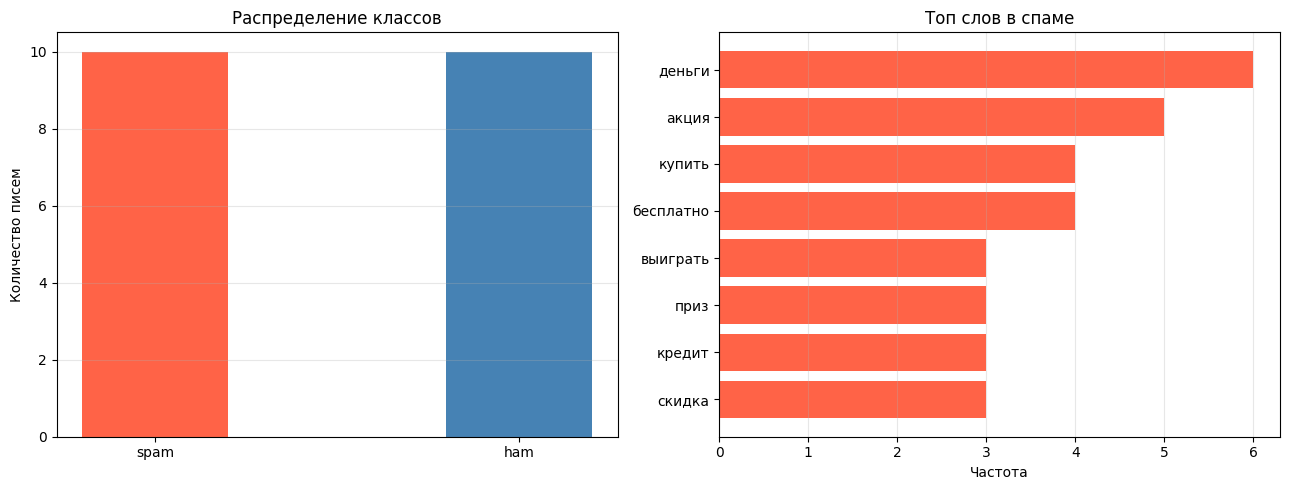

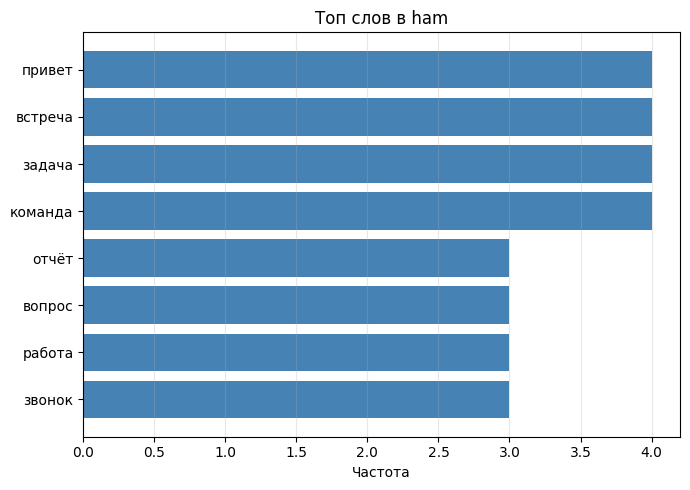

In [2]:
# Письма и их метки: (список слов, класс)
emails = [
    # spam
    (["купить", "виагру", "дёшево", "акция"],              "spam"),
    (["выиграть", "деньги", "бесплатно", "приз"],          "spam"),
    (["кредит", "быстро", "без", "отказа", "деньги"],      "spam"),
    (["акция", "скидка", "купить", "телефон", "дёшево"],   "spam"),
    (["заработать", "деньги", "быстро", "бесплатно"],      "spam"),
    (["приз", "выиграть", "акция", "подарок"],             "spam"),
    (["бесплатно", "кредит", "деньги", "заработать"],      "spam"),
    (["скидка", "купить", "акция", "предложение"],         "spam"),
    (["деньги", "выиграть", "приз", "бесплатно"],          "spam"),
    (["кредит", "купить", "скидка", "акция", "деньги"],    "spam"),
    # ham
    (["привет", "как", "дела", "встреча"],                 "ham"),
    (["отчёт", "по", "проекту", "готов", "задача"],        "ham"),
    (["встреча", "команда", "завтра", "вопрос"],           "ham"),
    (["работа", "проект", "задача", "команда"],            "ham"),
    (["обед", "встреча", "привет", "звонок"],              "ham"),
    (["вопрос", "по", "проекту", "работа"],                "ham"),
    (["задача", "выполнена", "отчёт", "команда"],          "ham"),
    (["звонок", "встреча", "вопрос", "привет"],            "ham"),
    (["проект", "работа", "отчёт", "задача"],              "ham"),
    (["привет", "обед", "команда", "звонок"],              "ham"),
]

labels  = [label for _, label in emails]
n_spam  = labels.count("spam")
n_ham   = labels.count("ham")
print(f"Всего писем: {len(emails)}  |  spam: {n_spam}  |  ham: {n_ham}")

# ── Визуализация ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Распределение классов
axes[0].bar(["spam", "ham"], [n_spam, n_ham], color=["tomato", "steelblue"], width=0.4)
axes[0].set_title("Распределение классов")
axes[0].set_ylabel("Количество писем")
axes[0].grid(True, alpha=0.3, axis="y")

# 2. Топ-8 слов по классам
spam_words = [w for words, lbl in emails if lbl == "spam" for w in words]
ham_words  = [w for words, lbl in emails if lbl == "ham"  for w in words]
top_spam = Counter(spam_words).most_common(8)
top_ham  = Counter(ham_words).most_common(8)

def plot_words(ax, top, color, title):
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Частота")
    ax.grid(True, alpha=0.3, axis="x")

plot_words(axes[1], top_spam, "tomato",    "Топ слов в спаме")

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5))
plot_words(ax2, top_ham, "steelblue", "Топ слов в ham")
plt.tight_layout()
plt.show()

## Алгоритм наивного Байеса

Наивный Байес — алгоритм классификации, основанный на теореме Байеса. Включает три составляющих:

**1. Априорная вероятность P(класс)**  
Доля писем каждого класса в обучающей выборке — вероятность класса без учёта содержимого письма.  
`P(спам) = кол-во спам-писем / всего писем`

**2. Правдоподобие P(слово | класс)**  
Вероятность встретить слово в письмах данного класса:  
`P(слово | спам) = кол-во спам-писем со словом / кол-во спам-писем`

Чтобы избежать нулевых вероятностей для слов, не встречавшихся в каком-либо классе, используется **сглаживание Лапласа** — счётчики инициализируются единицей.

**3. Апостериорная вероятность P(спам | текст)**  
По теореме Байеса перемножаем вероятности по всем словам словаря:
- слово **есть** в тексте → умножаем на `P(слово | класс)`  
- слова **нет** в тексте → умножаем на `1 − P(слово | класс)`

∏ - обозначает оператор произведения — последовательное умножение ряда чисел или элементов.
```
P(спам | текст) =        P(спам) · ∏ P(wᵢ | спам)
                  ─────────────────────────────────────────────────────
                  P(спам) · ∏ P(wᵢ | спам)  +  P(ham) · ∏ P(wᵢ | ham)
```

In [3]:
df = pd.DataFrame(emails)
df.columns = ['words', 'target']
df.sample(5)

,words,target
18,"[проект, работа, отчёт, задача]",ham
2,"[кредит, быстро, без, отказа, деньги]",spam
5,"[приз, выиграть, акция, подарок]",spam
9,"[кредит, купить, скидка, акция, деньги]",spam
13,"[работа, проект, задача, команда]",ham


In [4]:
spam_cnt = df[df.target == 'spam'].shape[0]
ham_cnt = df[df.target == 'ham'].shape[0]
total_cnt = spam_cnt+ham_cnt
print(f"{spam_cnt=} {ham_cnt=} {total_cnt=}")

spam_cnt=10 ham_cnt=10 total_cnt=20


In [5]:
pripor_spam_probability = spam_cnt/total_cnt
prior_ham_probability = ham_cnt/total_cnt
print(f"{pripor_spam_probability=} {prior_ham_probability=}")

pripor_spam_probability=0.5 prior_ham_probability=0.5


In [6]:
likelihood_words = {}
for words, target in df.values:
  for word in words:
    if word not in likelihood_words:
      likelihood_words[word] = {
        "spam": 1, "ham": 1
      }
    if target=='spam':
      likelihood_words[word]["spam"] += 1
    else:
      likelihood_words[word]["ham"] += 1

In [7]:
likelihood_words

{'купить': {'spam': 5, 'ham': 1},
 'виагру': {'spam': 2, 'ham': 1},
 'дёшево': {'spam': 3, 'ham': 1},
 'акция': {'spam': 6, 'ham': 1},
 'выиграть': {'spam': 4, 'ham': 1},
 'деньги': {'spam': 7, 'ham': 1},
 'бесплатно': {'spam': 5, 'ham': 1},
 'приз': {'spam': 4, 'ham': 1},
 'кредит': {'spam': 4, 'ham': 1},
 'быстро': {'spam': 3, 'ham': 1},
 'без': {'spam': 2, 'ham': 1},
 'отказа': {'spam': 2, 'ham': 1},
 'скидка': {'spam': 4, 'ham': 1},
 'телефон': {'spam': 2, 'ham': 1},
 'заработать': {'spam': 3, 'ham': 1},
 'подарок': {'spam': 2, 'ham': 1},
 'предложение': {'spam': 2, 'ham': 1},
 'привет': {'spam': 1, 'ham': 5},
 'как': {'spam': 1, 'ham': 2},
 'дела': {'spam': 1, 'ham': 2},
 'встреча': {'spam': 1, 'ham': 5},
 'отчёт': {'spam': 1, 'ham': 4},
 'по': {'spam': 1, 'ham': 3},
 'проекту': {'spam': 1, 'ham': 3},
 'готов': {'spam': 1, 'ham': 2},
 'задача': {'spam': 1, 'ham': 5},
 'команда': {'spam': 1, 'ham': 5},
 'завтра': {'spam': 1, 'ham': 2},
 'вопрос': {'spam': 1, 'ham': 4},
 'работа': {

In [8]:
import numpy as np

def model(input_text):
    input_words = set(input_text.split())
    spams, hams = [1.0], [1.0]

    for word, cnt in likelihood_words.items():
        p_spam = cnt['spam'] / spam_cnt
        p_ham  = cnt['ham']  / ham_cnt

        if word in input_words:
            spams.append(p_spam)
            hams.append(p_ham)
        else:
            spams.append(1 - p_spam)
            hams.append(1 - p_ham)

    score_spam = pripor_spam_probability * np.prod(spams)
    score_ham  = prior_ham_probability   * np.prod(hams)
    posterior  = round(score_spam / (score_spam + score_ham), 3)
    print(f"P(spam | '{input_text}') = {posterior}")
    return posterior

In [9]:
model("как обед кредит")

P(spam | 'как обед кредит') = 0.275


np.float64(0.275)

In [10]:
model("как обед кредит кредит")

P(spam | 'как обед кредит кредит') = 0.275


np.float64(0.275)

In [11]:
model("купить подарок быстро в кредит")

P(spam | 'купить подарок быстро в кредит') = 0.996


np.float64(0.996)

In [12]:
model("привет как дела")

P(spam | 'привет как дела') = 0.012


np.float64(0.012)